Best K found: 15
Best KNN Accuracy: 0.6730
Best KNN ROC-AUC: 0.5030

Random Forest Results:
Accuracy: 0.6784
F1 Score (High): 0.0910
ROC-AUC: 0.4981

Top 10 Feature Importances:
Price_USD              0.276729
Engine_Size_L          0.205588
Year                   0.156245
Transmission_Manual    0.033165
Fuel_Type_Hybrid       0.021107
Fuel_Type_Electric     0.021004
Fuel_Type_Petrol       0.020516
Region_Middle East     0.016203
Color_Red              0.015867
Region_Asia            0.015456
dtype: float64


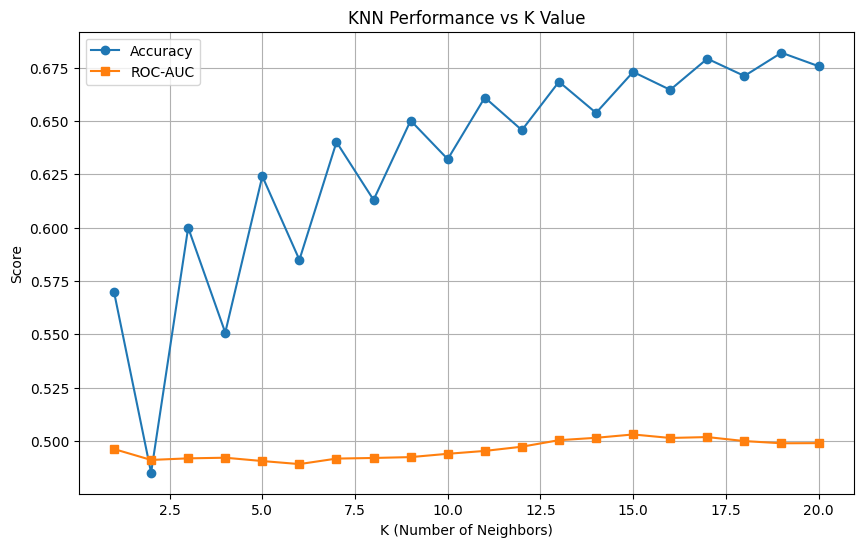

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Load data
file_path = "BMW sales data (2010-2024).csv"
df = pd.read_csv(file_path)

# Drop Mileage_KM (user request) and Sales_Volume (leakage)
df = df.drop(columns=['Mileage_KM', 'Sales_Volume'], errors='ignore')

# Separate X and y
X = df.drop('Sales_Classification', axis=1)
y = df['Sales_Classification']

# Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

# 1. Optimize KNN (Find best K)
k_values = range(1, 21)
accuracies = []
roc_aucs = []

lb = LabelBinarizer()
y_test_binary = lb.fit_transform(y_test)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]
    
    accuracies.append(accuracy_score(y_test, y_pred))
    roc_aucs.append(roc_auc_score(y_test_binary, y_pred_proba))

best_k_idx = np.argmax(roc_aucs)
best_k = k_values[best_k_idx]
best_acc = accuracies[best_k_idx]
best_roc = roc_aucs[best_k_idx]

print(f"Best K found: {best_k}")
print(f"Best KNN Accuracy: {best_acc:.4f}")
print(f"Best KNN ROC-AUC: {best_roc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, label='Accuracy', marker='o')
plt.plot(k_values, roc_aucs, label='ROC-AUC', marker='s')
plt.title('KNN Performance vs K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.savefig('knn_optimization.png')

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, pos_label='High')
rf_roc = roc_auc_score(y_test_binary, y_pred_proba_rf)

print("\nRandom Forest Results:")
print(f"Accuracy: {rf_acc:.4f}")
print(f"F1 Score (High): {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc:.4f}")

importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(10)
print("\nTop 10 Feature Importances:")
print(importances)